# Activity: Let's parse the United States Postal Service (USPS) Image Dataset
In this activity, you'll practice reading and parsing a real-world delimited dataset using Julia. The dataset contains images of handwritten digits used by the [United States Postal Service (USPS) for mail sorting](https://www.kaggle.com/datasets/bistaumanga/usps-dataset).

> __Learning Objectives__
> 
> By the end of this activity, you will be able to:
> * __Parse delimited text files:__ Read and parse space-delimited text files with nested delimiters using Julia's file I/O operations.
> * __Transform data representations:__ Convert raw pixel data from floating-point values to integer representations suitable for image processing.
> * __Decode vectorized images:__ Reconstruct 2D image arrays from flattened vector representations for visualization and analysis.


Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.


> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

### Constants
Set some constants that we will use later. Please look at the comments in the code for more details on each constant's permissible values, units, etc.

In [2]:
number_of_images_to_explore = 200; # how many images do we want to play with?
number_of_rows = 16;
number_of_cols = 16;
number_of_pixels = number_of_rows*number_of_cols;

### Helper Functions
Define any helper functions that we will use later. Please look at the comments in the code for more details on each function's purpose, inputs, outputs, etc.

> __What is going on in this code?__ The `decode` function converts a flattened 1D vector of pixel values back into a 2D image array that can be visualized. 
>
> First, we use [`reshape`](https://docs.julialang.org/en/v1/base/arrays/#Base.reshape) to transform the 1D vector into a 2D matrix with the specified number of rows and columns. Then we apply [`transpose`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#Base.transpose) to flip the rows and columns because images are typically stored in row-major order. 
>
> Finally, we use [`replace`](https://docs.julialang.org/en/v1/base/collections/#Base.replace) to convert `-1` values to `0` for proper grayscale rendering, where `0` represents black and `1` represents white.

Here is the implementation:

In [3]:
"""
Decode a vectorized image into a 2D array representation.

# Arguments
- `s::Vector{Int64}`: A vectorized image representation.
- `number_of_rows::Int=28`: Number of rows in the output image (default is 28).
- `number_of_columns::Int=28`: Number of columns in the output image (default is 28).

# Returns
- `Array{Int64,2}`: A 2D array representation of the image.
"""
function decode(s::Vector{Int64}; number_of_rows::Int=28, number_of_columns::Int = 28)::Array{Int64,2}

    # reconstructed image -
    X = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0);
    
    # return -
    return X̂
end;

___

## Task 1: Let's build a parser for the USPS dataset
The USPS dataset is stored in a space delimited text file. Each line in the file represents a single image of a handwritten digit. The first value in each line is the label (the digit + 1 that the image represents), followed by 256 pixel values (16x16 image) ranging from 1 to 256. 

> For example, a sample record might look like this:
>
> ```
> 7 1:-1.000000 2:-1.000000 3:-1.000000 4:-0.999997 5:-0.999729 6:-0.989537 ... 256:-0.999994
> ```
> 
> This line represents an image of the digit `6` (since the label is 7), and the pixel values follow, where each pixel value is represented as `index:value`. The index indicates the position of the pixel in the flattened 16x16 image, and the value is the pixel intensity normalized between -1 and 1.

This is an interesting example because it shows how the fields are delimited by spaces, but within each field (after the first), there is a further delimiter (the colon `:`) separating the index and value. Very clever design! 

Let's use the `open ... do` construct to read the file line by line, and then use string manipulation functions to parse each line into its components. Let's build a function called `MyUSPSHandwrittenDigitImageDataset` that takes the path to the dataset file as an argument and returns a `NamedTuple` containing two elements: `records` and `labels`.

> __What is going on in this code?__ The function opens the file and reads each line. For each line, it uses [`split`](https://docs.julialang.org/en/v1/base/strings/#Base.split) to tokenize the string—breaking it into an array of substrings separated by spaces. 
>
> This is crucial because `split` returns an array of **strings**, not numbers. To convert these string representations into numeric values, we use [`parse`](https://docs.julialang.org/en/v1/base/numbers/#Base.parse), which takes a type (like `Int` or `Float64`) and a string, and returns the corresponding numeric value. 
>
> The first field is the label, which we parse as an `Int`. The remaining fields contain pixel data in the format `index:value`, so we split each field again (this time on the colon `:`) and parse both parts. The pixel values are stored in a dictionary with the pixel index as the key and the intensity as the value. 
>
> The function returns a `NamedTuple` with two fields: `records` (a dictionary of pixel data) and `labels` (an array of digit labels).

In [ ]:
function MyUSPSHandwrittenDigitImageDataset(;path::String = "", number_of_fields::Int = 256)::NamedTuple

    # initialize -
    records = Dict{Int, Array{Float64, 1}}();
    labels = Array{Int, 1}();
    
    # check: is the path legit? 
    pathtodtafile = path; # assume the user provided a path if correct, then check. Trust, but verify!
    if (isfile(pathtodtafile) == false)
        error("The path provided to the data file is not valid: ", pathtodtafile);
    end

    # open the file, process each line -
    linecounter = 1;
    open(pathtodtafile, "r") do io # open a stream to the file
        for line ∈ eachline(io)
            
            # fields -
            fields = split(line, " "); # do an initial split around spaces
            y = parse(Int, fields[1]) - 1; # first field is the Int label make 0,9 instead of 1,10
            push!(labels, y); # store the label in the labels array
            
            # split around the : character -
            record = Dict{Int, Float64}();
            for field ∈ fields[2:end]

                if (isempty(field) == false)
                    # split the field around the : character -
                    key, value = split(field, ":"); # key is pixel index, value is pixel intensity
                    key = parse(Int, key); # we want Int keys
                    value = parse(Float64, value); # we want Float64 values
                    record[key] = value; # store in the record dict
                end
            end

            # store the record -
            records[linecounter] = [record[i] for i ∈ 1:number_of_fields]; # wow! That is slick. Check out comprehensions if you haven't seen them before.
            linecounter += 1;
        end
    end

    # build a result NamedTuple, this is a nice way to return multiple values from a function
    result = (records = records, labels = labels);
    return result;
end

MyUSPSHandwrittenDigitImageDataset (generic function with 1 method)

___

## Task 2: Load and Explore the Data
In this task, let's load the USPS dataset by calling the `MyUSPSHandwrittenDigitImageDataset(...)` method, transform the data to the `{-1,1}` (integer) scale, and then return this (rescaled) data to the caller in the `X::Array{Int,2}` array, where the images are encoded in the columns of the array.

> __What is in the `X` array?__ Each column of the `X::Array{Int,2}` array holds one of the `7291` handwritten images. Each row is a pixel value; a total of `256` pixels per image. We also return the `raw_data_dictionary::Dict{Int64, Vector{Float64}}` dictionary that holds the raw (untransformed) data vectors for each image.

> __What's in the labels array?__ The `labels::Vector{Int}` array holds the actual digit (0-9) corresponding to each image in the `X` array.

Now let's call our parser function and transform the floating-point pixel values into a simpler integer format:

In [5]:
X, labels = let

    # load the dataset
    pathtodtafile = joinpath(_PATH_TO_DATA, "usps-labels-numbers.data"); # where is the datafile?
    results = MyUSPSHandwrittenDigitImageDataset(path = pathtodtafile);  # pass the path to our parser function
    
    # the results tuple has two fields: records, and labels
    records = results.records; # pixel data
    labels = results.labels; # labels
    number_of_records = length(labels);

    # initialize storage for the (rescaled) pixel data
    X = Array{Int,2}(undef, number_of_pixels, number_of_records);

    for i ∈ 1:number_of_records
        record = records[i]; # grab the pixel dictionary
        for k ∈ 1:number_of_pixels

            # we want pixel data to be on a -1,1 Int scale
            X[k,i] = (record[k] ≤ 0.0) ? -1 : 1; # wow! that is legit .. but hard to follow.

            # same idea: not as cool, but easier to read?
            # if (record[k] ≤ 0.0) # we want Int values, not floating point
            #     X[k,i] = -1;
            # else
            #     X[k,i] = 1;
            # end
        end
    end

    X[:,1:number_of_images_to_explore], labels[1:number_of_images_to_explore]
end;

Let's check the (rescaled) data. 

> __What is going on in this code?__ The code randomly selects one image from the dataset, decodes it from a vectorized form into a 2D array, converts it to a grayscale image, and displays it. This allows us to visually verify that the data was parsed correctly.

So what do we see?

Selected index = 128 has label = 2


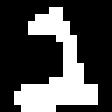

In [9]:
let

    # initialize -
    number_of_records = length(labels);
    i = rand(1:number_of_records);

    println("Selected index = $(i) has label = $(labels[i])")
    X[:,i] |> s-> decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols) |> img -> Gray.(img)
end

___

## Summary
This activity demonstrated how to parse the USPS handwritten digit dataset, a space-delimited file with nested colon-delimited fields, and transform the data into a format suitable for image processing.

> __Key Takeaways:__
> 
> * **Nested delimiters:** Real-world datasets often use multiple levels of delimiters; the USPS dataset uses spaces to separate fields and colons to separate pixel indices from values within each field.
> * **Data transformation:** Raw pixel data in floating-point format can be rescaled to integer values (e.g., -1 and 1) to simplify downstream processing and reduce memory usage.
> * **Vector to matrix conversion:** Flattened image vectors can be reshaped into 2D arrays using `reshape` and `transpose` operations, enabling visualization and spatial analysis of image data.

The techniques demonstrated here, i.e., parsing complex delimited files, transforming data types, and reshaping arrays are fundamental skills for working with real-world datasets in scientific computing. 

___